In [1]:
import numpy as np
from ase import Atoms, io
from DynamicTopology.ase import DynamicTopology
from DynamicTopology.core import ReactionSet
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
reaction_set = ReactionSet("../datasets/HCombustion/HCombustion.json")

In [3]:
def compute_energies(frames: list[Atoms]):
    energies = []
    diagnostics = []
    for frame in frames:
        frame.calc = DynamicTopology(frame, reaction_set)
        energy = frame.get_potential_energy()
        energies.append(energy)
        diagnostics.append(frame.calc.diagnostics)
    return energies, diagnostics

In [4]:
atoms = Atoms(symbols=["H", "H"], positions=[[0, 0, 0], [1, 0, 0]])
atoms.info["connectivity"] = [(0, 1, None)]

frames = []
xaxis = np.linspace(0.1, 10.0, 100)
for dx in xaxis:
    mol = atoms.copy()
    mol.positions[1][0] = dx
    frames.append(mol)
print(frames)

[Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(symbols='H2', pbc=False), Atoms(s

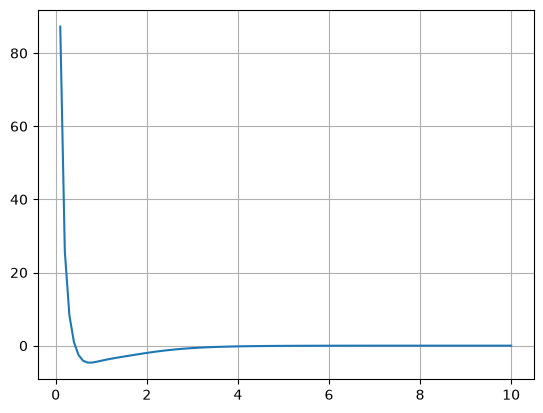

In [5]:
energies, diagnostics = compute_energies(frames)

plt.figure()
plt.plot(xaxis, energies)
plt.grid()
plt.show()